In [1]:
import os, re, glob
!nvidia-smi -L
!apt-get update -qq > /dev/null 2>&1
!apt-get install -y -qq libopencv-dev > /dev/null && echo "OPENCV OK"

%cd /content
if not os.path.exists('/content/udacity-cs344-colab/src'):
    !rm -rf /content/udacity-cs344-colab
    !git clone https://github.com/depctg/udacity-cs344-colab
%cd /content/udacity-cs344-colab

# compilar para la T4 (sm_75)
p = 'src/CMakeLists.txt'
s = open(p).read()
s = re.sub(r'set\(CUDA_NVCC_FLAGS ".*?"\)',
           'set(CUDA_NVCC_FLAGS "-gencode;arch=compute_75,code=sm_75")', s, flags=re.S)
open(p, 'w').write(s)

# constantes de OpenCV 4
for f in glob.glob('src/HW1/*.cpp'):
    t = open(f).read()
    t = (t.replace('CV_LOAD_IMAGE_COLOR', 'cv::IMREAD_COLOR')
          .replace('CV_LOAD_IMAGE_GRAYSCALE', 'cv::IMREAD_GRAYSCALE')
          .replace('CV_BGR2RGBA', 'cv::COLOR_BGR2RGBA'))
    open(f, 'w').write(t)

!rm -rf build && mkdir build
%cd build
!cmake ../src -DCMAKE_POLICY_VERSION_MINIMUM=3.5 2>&1 | tail -5

GPU 0: Tesla T4 (UUID: GPU-10ffbf36-ef12-b32d-bd4f-0d077e26dba0)
OPENCV OK
/content
Cloning into 'udacity-cs344-colab'...
remote: Enumerating objects: 144, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 144 (delta 14), reused 12 (delta 12), pack-reused 120 (from 1)
Receiving objects: 100% (144/144), 3.93 MiB | 33.02 MiB/s, done.
Resolving deltas: 100% (43/43), done.
/content/udacity-cs344-colab
/content/udacity-cs344-colab/build

    CMAKE_POLICY_VERSION_MINIMUM


-- Build files have been written to: /content/udacity-cs344-colab/build


In [2]:
%%writefile /content/udacity-cs344-colab/src/HW1/student_func.cu
#include "utils.h"

__global__
void rgba_to_greyscale(const uchar4* const rgbaImage,
                       unsigned char* const greyImage,
                       int numRows, int numCols)
{
  // Cada hilo procesa un píxel: x -> columna, y -> fila
  int col = blockIdx.x * blockDim.x + threadIdx.x;
  int row = blockIdx.y * blockDim.y + threadIdx.y;

  // Hilos que caen fuera de la imagen no hacen nada
  if (row >= numRows || col >= numCols) return;

  // La imagen está guardada fila por fila
  int idx = row * numCols + col;

  uchar4 px = rgbaImage[idx];
  greyImage[idx] = (unsigned char)(.299f * px.x + .587f * px.y + .114f * px.z);
}

void your_rgba_to_greyscale(const uchar4 * const h_rgbaImage, uchar4 * const d_rgbaImage,
                            unsigned char* const d_greyImage, size_t numRows, size_t numCols)
{
  const dim3 blockSize(16, 16, 1);                 // 256 hilos por bloque
  const dim3 gridSize((numCols + 15) / 16,         // bloques en x, redondeando hacia arriba
                      (numRows + 15) / 16, 1);     // bloques en y
  rgba_to_greyscale<<<gridSize, blockSize>>>(d_rgbaImage, d_greyImage, numRows, numCols);

  cudaDeviceSynchronize(); checkCudaErrors(cudaGetLastError());
}

Overwriting /content/udacity-cs344-colab/src/HW1/student_func.cu


In [3]:
%cd /content/udacity-cs344-colab/build
!make HW1
print("\n====== RESULT OF HW1 =======\n")
!bin/HW1 ../src/HW1/cinque_terre_small.jpg

/content/udacity-cs344-colab/build
[ 20%] Building NVCC (Device) object HW1/CMakeFiles/HW1.dir/HW1_generated_student_func.cu.o
[ 40%] Building CXX object HW1/CMakeFiles/HW1.dir/main.cpp.o
[ 60%] Building CXX object HW1/CMakeFiles/HW1.dir/reference_calc.cpp.o
[ 80%] Building CXX object HW1/CMakeFiles/HW1.dir/compare.cpp.o
[100%] Linking CXX executable ../bin/HW1
[100%] Built target HW1

====== RESULT OF HW1 =======

Your code ran in: 0.185312 msecs.
PASS


/content/udacity-cs344-colab/build


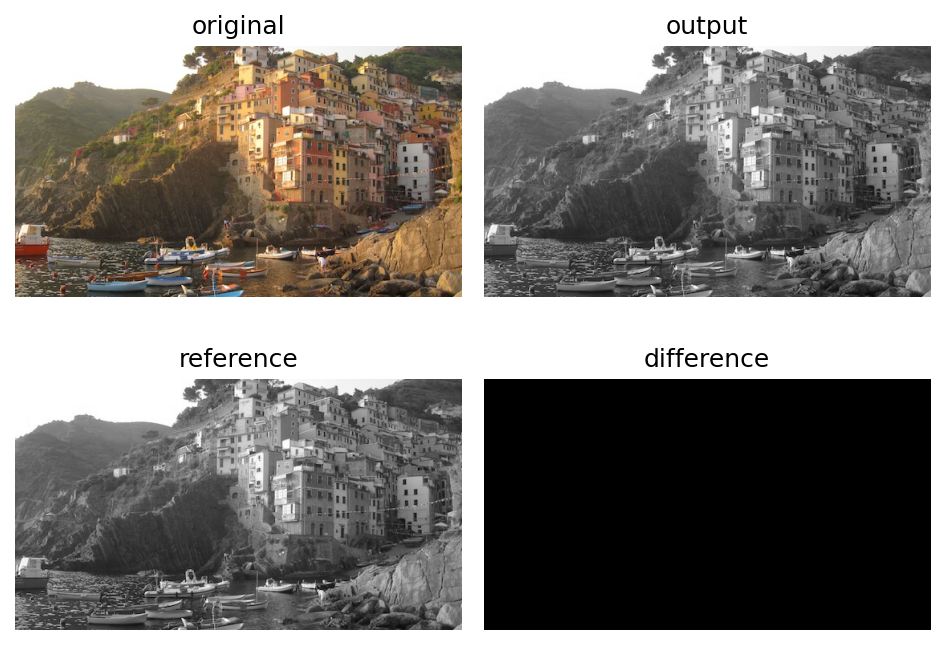

In [4]:
import os
import matplotlib.pyplot as plt

%cd /content/udacity-cs344-colab/build

imagenes = [
    ("original",   "../src/HW1/cinque_terre_small.jpg"),
    ("output",     "HW1_output.png"),
    ("reference",  "HW1_reference.png"),
    ("difference", "HW1_differenceImage.png"),
]

fig, ax = plt.subplots(2, 2, dpi=150)
for a, (titulo, ruta) in zip(ax.flat, imagenes):
    if os.path.exists(ruta):
        img = plt.imread(ruta)
        a.imshow(img, cmap="gray" if img.ndim == 2 else None)
    else:
        a.text(0.5, 0.5, "no existe", ha="center", va="center")
    a.set_title(titulo)
    a.axis("off")
plt.tight_layout()
plt.show()